In [18]:
import tensorflow as tf
from tensorflow import keras
from keras import layers
import random
import os
import numpy as np
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score, confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


### Data preparation

In [19]:
def load_data_and_labels(data_set_path: str, target_size: tuple):
    try:
        data, labels, label_names = [], [], []
        for class_number, class_name in enumerate(os.listdir(data_set_path)):
            full_path = os.path.join(data_set_path, class_name)

            label_names.append(class_name)

            for img in os.listdir(f"{full_path}"):
                full_path_to_image = os.path.join(*[full_path, img])
                labels.append(class_number)
                image = tf.keras.utils.load_img(full_path_to_image, target_size=target_size)
                image = tf.keras.utils.img_to_array(image)
                data.append(image)

        return np.array(data, dtype='float32'), np.array(labels, dtype='int'), label_names
    except Exception as ex:
        print(f"[EXCEPTION] {ex}")

In [20]:
X_train, y_train, y_train_labels = load_data_and_labels('/content/drive/MyDrive/computer_vision_and_sensor_fusion/Datasets/cookies_vs_chihuahua/train', [224,224,3])
X_test, y_test, y_test_labels = load_data_and_labels('/content/drive/MyDrive/computer_vision_and_sensor_fusion/Datasets/cookies_vs_chihuahua/test', [224,224,3])

In [21]:
# Data check

print('X_train shape:', X_train.shape)
print('Y_test shape:', X_test.shape)
print('y_train shape:', y_train.shape)
print('y_test shape:', y_test.shape)
df, df2 = pd.DataFrame(y_train), pd.DataFrame(y_train_labels)
print('Labels:', df[0].unique(), df2[0].unique())

X_train shape: (4733, 224, 224, 3)
Y_test shape: (1184, 224, 224, 3)
y_train shape: (4733,)
y_test shape: (1184,)
Labels: [0 1] ['chihuahua' 'muffin']


In [22]:
# Data normalization

X_train /= 255
X_test /= 255

### Model creation

In [23]:
# Data augmentation to get more out of the training set, convolution layers to map features, pooling for downsampling,
# normalization to speed up the training and dense layers for classification.
# For multiclass the final layer units should be the amount of classes with softmax activation
# The architecture is kept relatively simple since it's meant to be used for classification on a limited dataset

data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
  ])

model = keras.Sequential([
          layers.Input(shape=(224,224,3)),
          data_augmentation,
          layers.Conv2D(filters=16, kernel_size=(2,2), padding="same", activation="relu"),
          layers.MaxPool2D(pool_size=(2,2)),
          layers.BatchNormalization(),
          layers.Conv2D(filters=24, kernel_size=(2,2), padding="same", activation="relu"),
          layers.MaxPool2D(pool_size=(2,2)),
          layers.BatchNormalization(),
          layers.Flatten(),
          layers.Dense(units=8, activation="relu"),
          layers.Dense(units=1, activation="sigmoid"),
      ])

print (model.summary())

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ sequential_2 (Sequential)            │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 224, 224, 16)        │             208 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 112, 112, 16)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 112, 112, 16)        │              64 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 112, 112, 24)        │           1,560 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 56, 56, 24)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 56, 56, 24)          │              96 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 75264)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 8)                   │         602,120 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │               9 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 604,057 (2.30 MB)

 Trainable params: 603,977 (2.30 MB)

 Non-trainable params: 80 (320.00 B)

None


In [24]:
# For multiclass the loss should be categorical crossentropy, keras picks the right kind of accuracy based on the loss function
model.compile(optimizer='adam', loss=tf.keras.losses.BinaryCrossentropy(), metrics=['accuracy'])

In [25]:
# Limited epochs to avoid overfitting
model.fit(x=X_train, y=y_train, batch_size=64, epochs=50)

Epoch 1/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 9s 63ms/step - accuracy: 0.6743 - loss: 0.9197
Epoch 2/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 5s 62ms/step - accuracy: 0.8204 - loss: 0.5110
Epoch 3/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 6s 68ms/step - accuracy: 0.8392 - loss: 0.4838
Epoch 4/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 5s 62ms/step - accuracy: 0.8414 - loss: 0.4536
Epoch 5/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 5s 64ms/step - accuracy: 0.8499 - loss: 0.3557
Epoch 6/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 5s 68ms/step - accuracy: 0.8752 - loss: 0.2901
Epoch 7/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 5s 62ms/step - accuracy: 0.8807 - loss: 0.2742
Epoch 8/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 5s 66ms/step - accuracy: 0.8883 - loss: 0.2768
Epoch 9/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 5s 65ms/step - accuracy: 0.9087 - loss: 0.2293
Epoch 10/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 5s 62ms/step - accuracy: 0.8895 - loss: 0.2447
Epoch 11/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 5s 69ms/step - accuracy: 0.9080 - loss: 0.2147
Epoch 12/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 5s 62ms/step - accuracy:

### Evaluation of the model

In [26]:
scores = model.evaluate(X_test, y_test, verbose=2)
print("%s: %.2f%%" % (model.metrics_names[1], scores[1]*100))

37/37 - 1s - 21ms/step - accuracy: 0.9012 - loss: 0.3530
compile_metrics: 90.12%


In [27]:
# Predictions with the test set
predictions = model.predict(X_test)

37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step


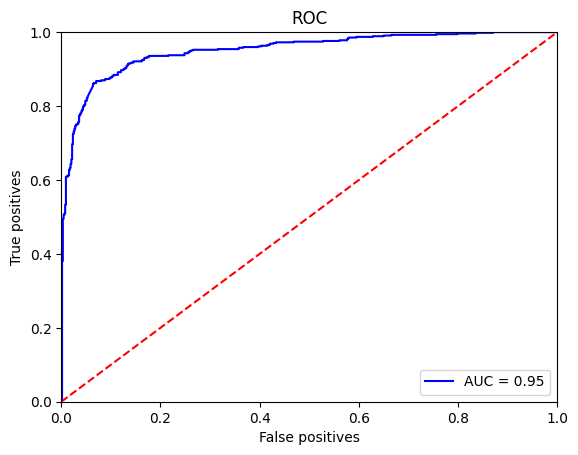

In [28]:
# ROC
fpr, tpr, threshold = roc_curve(y_test, predictions)
roc_auc = auc(fpr, tpr)

plt.title('ROC')
plt.ylabel('True positives')
plt.xlabel('False positives')
plt.plot(fpr, tpr, 'b', label = 'AUC = %0.2f' % roc_auc)
plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.show()

In [29]:
# Calculating best threshold, as there are no costs associated the only basis is performance
thresholds = np.arange(0.1, 1.0, 0.1)

best_threshold = 0
best_performance = 0

for threshold in thresholds:
    pred_classes = np.where(predictions > threshold, 1, 0)
    performance = accuracy_score(y_test, pred_classes)
    if performance > best_performance:
        best_performance = performance
        best_threshold = threshold

print(f"Best threshold: {best_threshold}")
print(f"Best performance: {best_performance}")

Best threshold: 0.5
Best performance: 0.9011824324324325


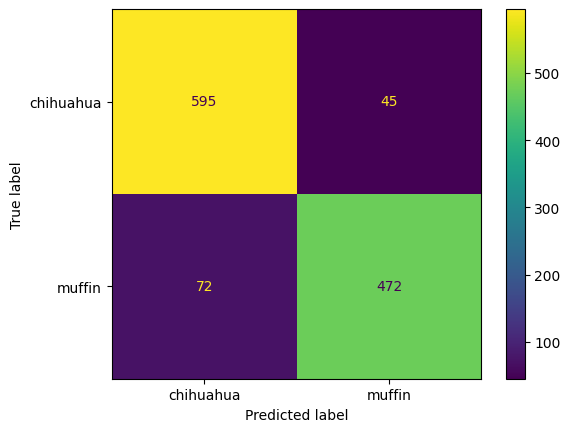

In [30]:
# Confusion matrix with the best threshold
pred_classes = np.where(predictions > best_threshold, 1, 0)
cf_matrix = confusion_matrix(y_test, pred_classes)
cf_plot = ConfusionMatrixDisplay(confusion_matrix=cf_matrix, display_labels=y_test_labels)
cf_plot.plot()
plt.show()